[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter18_seminar_notebook.ipynb)

# Modelling Financial Markets — Seminar 18: Systemic Risk and Networks

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems name their model (the solved problem with the same technique).

> The solutions are discussed in the seminar.

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from sklearn.linear_model import QuantileRegressor
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'   # doar linii de referinta, benzi, grila
REGION_COL = {'US': MainBlue, 'EU': IDAred, 'RO': Forest}
REGION_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (BVB)'}
EVENTS = [('2011-08-08', 'Euro crisis'), ('2016-06-24', 'Brexit vote'), ('2018-12-19', 'RO bank tax'),
          ('2020-03-16', 'COVID-19'), ('2023-03-13', 'SVB'), ('2025-04-07', 'Tariffs')]

HERE = '.'
SEED = 42
B_BOOT = 200
RESULTS = {}


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [jsonable(v) for v in x]
    if isinstance(x, np.ndarray):
        return [jsonable(v) for v in x.tolist()]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def mark_events(ax, ymax=None):
    """Linii verticale de referinta pentru evenimente, cu eticheta neagra."""
    for d, lab in EVENTS:
        t = pd.Timestamp(d)
        if ax.get_xlim()[0] <= mdates.date2num(t) <= ax.get_xlim()[1]:
            ax.axvline(t, color=Gray, lw=0.5, ls=':')
            ax.text(t, ax.get_ylim()[1] if ymax is None else ymax, lab, rotation=90, fontsize=6.5, color='black',
                    ha='right', va='top')


import tempfile
HERE = tempfile.gettempdir()   # intermediate tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily prices, January 2010 – 18 September 2026: six US banks, five European banks, Banca Transilvania and BRD; S&P 500, Euro Stoxx 50, BET, VIX.
- Prices joined on common trading days, then daily log returns in %; volatility: daily Parkinson range estimator.
- Romanian banks: days without trades removed.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
START = '2010-01-01'
END = '2026-09-18'

# banca -> (simbol, nume, regiune)
BANKS = {
    'JPM':  ('JPM.US',    'JPMorgan Chase',       'US'),
    'BAC':  ('BAC.US',    'Bank of America',      'US'),
    'C':    ('C.US',      'Citigroup',            'US'),
    'GS':   ('GS.US',     'Goldman Sachs',        'US'),
    'MS':   ('MS.US',     'Morgan Stanley',       'US'),
    'WFC':  ('WFC.US',    'Wells Fargo',          'US'),
    'DBK':  ('DBK.XETRA', 'Deutsche Bank',        'EU'),
    'BNP':  ('BNP.PA',    'BNP Paribas',          'EU'),
    'SAN':  ('SAN.MC',    'Santander',            'EU'),
    'INGA': ('INGA.AS',   'ING',                  'EU'),
    'HSBA': ('HSBA.LSE',  'HSBC',                 'EU'),
    'TLV':  ('TLV.RO',    'Banca Transilvania',   'RO'),
    'BRD':  ('BRD.RO',    'BRD-Groupe SG',        'RO'),
}
US = [k for k, v in BANKS.items() if v[2] == 'US']
EU = [k for k, v in BANKS.items() if v[2] == 'EU']
RO = [k for k, v in BANKS.items() if v[2] == 'RO']
ALL = US + EU + RO
NAMES = {k: v[1] for k, v in BANKS.items()}
INDICES = {'SPX': ('GSPC.INDX', 'S&P 500'), 'SX5E': ('STOXX50E.INDX', 'Euro Stoxx 50'),
           'BET': ('BET', 'BET'), 'VIX': ('VIX.INDX', 'VIX')}
REGION_INDEX = {'US': 'SPX', 'EU': 'SX5E', 'RO': 'BET'}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def bank_frame(key, start=START, end=END):
    """OHLCV al unei banci, cu pretul ajustat si corectiile de mai sus."""
    symbol, _, region = BANKS[key]
    d = read_market(symbol).loc[start:end].copy()
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if region == 'RO':
        d = d[d['volume'] > 0]                                   # zile fara tranzactii
    if key == 'TLV' and pd.Timestamp('2016-05-30') in d.index:
        # ajustarea pentru actiunile gratuite: factorul de dupa data ex se aplica si pe 30 mai 2016
        f = d.loc['2016-05-31', 'adjusted_close'] / d.loc['2016-05-31', 'close']
        d.loc['2016-05-30', 'adjusted_close'] = d.loc['2016-05-30', 'close'] * f
    return d


def bank_price(key, start=START, end=END):
    return bank_frame(key, start, end)['adjusted_close'].rename(key)


def index_close(key, start=START, end=END):
    s = read_market(INDICES[key][0])['close'].loc[start:end]
    s = s[(s.index.dayofweek < 5) & (s > 0)].dropna()
    if key != 'VIX':
        s = s[s.diff() != 0]                                     # sarbatori completate cu pretul anterior
    return s.rename(key)


def prices(keys, start=START, end=END):
    """Preturi zilnice pentru banci si/sau indici, doar in zilele comune."""
    cols = [bank_price(k, start, end) if k in BANKS else index_close(k, start, end) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def joint_returns(keys, start=START, end=END):
    """Randamente log zilnice in %: intai join pe PRETURI in zilele comune, apoi randamente."""
    return 100 * np.log(prices(keys, start, end)).diff().dropna()


def bank_range_vol(keys, start=START, end=END):
    """Volatilitatea zilnica Parkinson (in %, anualizata), in zilele comune tuturor bancilor."""
    out = []
    for k in keys:
        d = bank_frame(k, start, end)
        rng = np.log(d['high'] / d['low']).where(d['high'] > d['low'])
        s2 = rng ** 2 / (4 * np.log(2))
        s2 = s2.fillna(s2[s2 > 0].min())                          # zile cu maxim = minim: cea mai mica valoare observata
        out.append((100 * np.sqrt(252 * s2)).rename(k))
    return pd.concat(out, axis=1, join='inner').dropna()


def system_return(R, members):
    """Randamentul sistemului: portofoliul cu ponderi egale al bancilor (randamente log in %, aproximare zilnica)."""
    return R[members].mean(axis=1)


# randamente log zilnice in % (zile comune) si volatilitatea Parkinson (log)
R = joint_returns(ALL + ['SPX', 'SX5E', 'BET', 'VIX'])
V = np.log(bank_range_vol(ALL))
print(R.index[0].date(), '->', R.index[-1].date(), len(R), 'common days')


def system_ex(k, members):
    """Randamentul sistemului regional fara banca k (portofoliu cu ponderi egale)."""
    return R[[j for j in members if j != k]].mean(axis=1)


def region_of(k):
    return BANKS[k][2]

## Systemic risk measures

- `mes`, `lrmes`, `srisk_ratio`, `breakeven_leverage`: exposure measures.
- `qreg`, `covar_static`, `covar_boot`, `covar_dynamic`: CoVaR by quantile regression, with a moving-block bootstrap.
- `var_fit`, `gfevd`, `spillover_table`, `rolling_total`: Diebold–Yilmaz connectedness.
- `lasso_qr_gacv`: L1-penalized quantile regression with the penalty chosen by GACV (Financial Risk Meter).

In [ ]:
def mes(r_i, r_m, alpha=0.05):
    """MES (%): pierderea medie a bancii in zilele in care piata este in coada de probabilitate alpha."""
    q = np.quantile(r_m, alpha)
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) <= q])


def mes_threshold(r_i, r_m, c=-2.0):
    """MES (%) in zilele in care piata scade cu mai mult de |c|% (definitia folosita pentru LRMES)."""
    return -np.mean(np.asarray(r_i)[np.asarray(r_m) < c])


def lrmes(mes2_pct):
    """Pierderea pe termen lung intr-o criza (piata -40% in sase luni): LRMES = 1 - exp(-18 MES), MES in fractii."""
    return 1 - np.exp(-18 * mes2_pct / 100)


def srisk_ratio(lrm, leverage, k=0.08):
    """SRISK / capitalul de piata W: k(L - 1) - (1 - k)(1 - LRMES), cu L = (D + W)/W."""
    return k * (leverage - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=0.08):
    """Levierul L* peste care SRISK > 0: L* = 1 + (1 - k)(1 - LRMES)/k."""
    return 1 + (1 - k) * (1 - lrm) / k


def qreg(y, X, q):
    """Regresie cuantila (Koenker-Bassett); intoarce coeficientii [termen liber, pante]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar_static(x_sys, x_i, alpha=0.01):
    """CoVaR si Delta-CoVaR necondiționate (%, pozitive = pierderi).

    Regresia cuantila la nivelul alpha: X_sys = a + b X_i;
    CoVaR_alpha = -(a + b q_alpha(X_i)); Delta-CoVaR = b (q_50(X_i) - q_alpha(X_i))."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': a, 'b': b, 'var_i': -qa, 'covar': -(a + b * qa), 'covar_med': -(a + b * qm),
            'dcovar': b * (qm - qa), 'var_sys': -np.quantile(x_sys, alpha)}


def block_bootstrap_idx(n, block=20, rng=None):
    """Indici pentru bootstrap pe blocuri mobile (Künsch), blocuri de lungime fixa."""
    rng = rng or np.random.default_rng(0)
    starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_boot(x_sys, x_i, alpha=0.01, B=200, block=20, seed=0):
    """Interval percentil de 95% pentru Delta-CoVaR prin bootstrap pe blocuri mobile."""
    x_sys, x_i = np.asarray(x_sys), np.asarray(x_i)
    rng = np.random.default_rng(seed)
    d = []
    for _ in range(B):
        idx = block_bootstrap_idx(len(x_i), block, rng)
        d.append(covar_static(x_sys[idx], x_i[idx], alpha)['dcovar'])
    return np.percentile(d, [2.5, 97.5])


def covar_dynamic(x_sys, x_i, M, alpha=0.01):
    """Delta-CoVaR variabil in timp cu variabile de stare M_{t-1} (Adrian & Brunnermeier, 2016).

    X_i,t = a + c'M_{t-1} la nivelurile alpha si 50%  ->  VaR_i,t;
    X_sys,t = a + b X_i,t + c'M_{t-1} la nivelul alpha  ->  Delta-CoVaR_t = b (q50_i,t - qalpha_i,t)."""
    ci_a = qreg(x_i, M, alpha)
    ci_m = qreg(x_i, M, 0.5)
    cs = qreg(x_sys, np.column_stack([x_i, M]), alpha)
    Mc = sm.add_constant(np.asarray(M), has_constant='add')
    qa, qm = Mc @ ci_a, Mc @ ci_m
    return pd.DataFrame({'var_i': -qa, 'dcovar': cs[1] * (qm - qa)}, index=getattr(x_i, 'index', None)), cs[1]


def var_fit(Y, p):
    """VAR(p) estimat prin OLS; intoarce coeficientii A_1..A_p (k x k) si matricea de covarianta a reziduurilor."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    Yt = Y[p:]
    B = np.linalg.lstsq(X, Yt, rcond=None)[0]
    E = Yt - X @ B
    S = E.T @ E / (len(Yt) - X.shape[1])
    A = [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)]
    return A, S


def var_bic(Y, pmax=5):
    """Ordinul VAR ales prin criteriul BIC."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    best = None
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        n = T - pmax
        bic = np.log(np.linalg.det(S)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def ma_coefs(A, H):
    """Coeficientii reprezentarii medie mobila Phi_0..Phi_{H-1}."""
    k = A[0].shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    return Phi


def gfevd(A, S, H=10):
    """Descompunerea generalizata a dispersiei erorii de prognoza (Pesaran-Shin), normalizata pe linii."""
    Phi = ma_coefs(A, H)
    k = S.shape[0]
    num = np.zeros((k, k))
    den = np.zeros(k)
    for P in Phi:
        PS = P @ S
        num += PS ** 2
        den += np.diag(P @ S @ P.T)
    theta = num / np.diag(S)[None, :] / den[:, None]
    return theta / theta.sum(axis=1, keepdims=True)


def spillover_table(theta, names):
    """Tabelul de conectivitate: contributii (%), FROM, TO, NET si indicele total."""
    k = theta.shape[0]
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    tab = pd.DataFrame(D, index=names, columns=names)
    return {'table': tab, 'from': pd.Series(frm, index=names), 'to': pd.Series(to, index=names),
            'net': pd.Series(to - frm, index=names), 'total': off.sum() / k,
            'pairwise_net': pd.DataFrame(off.T - off, index=names, columns=names)}


def rolling_total(Y, window=250, step=5, p=2, H=10):
    """Indicele total de conectivitate pe ferestre mobile."""
    Y = pd.DataFrame(Y)
    out, frm_to = {}, {}
    for end in range(window, len(Y) + 1, step):
        w = Y.iloc[end - window:end]
        A, S = var_fit(w.values, p)
        st = spillover_table(gfevd(A, S, H), list(Y.columns))
        out[Y.index[end - 1]] = st['total']
        frm_to[Y.index[end - 1]] = st['net']
    return pd.Series(out), pd.DataFrame(frm_to).T


def check_loss(u, tau):
    return u * (tau - (u < 0))


def lasso_qr_gacv(y, X, tau=0.05, lambdas=None):
    """Regresie cuantila penalizata L1; lambda ales prin GACV = sum rho_tau(rez) / (n - df)."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    n = len(y)
    lambdas = np.logspace(-4, -0.5, 15) if lambdas is None else lambdas
    rows = []
    for lam in lambdas:
        m = QuantileRegressor(quantile=tau, alpha=lam, solver='highs').fit(X, y)
        res = y - m.predict(X)
        df = int(np.sum(np.abs(m.coef_) > 1e-8))
        g = check_loss(res, tau).sum() / max(n - df, 1)
        rows.append((lam, g, df, m.coef_.copy()))
    i = int(np.argmin([r[1] for r in rows]))
    return {'lambda': rows[i][0], 'gacv': [r[1] for r in rows], 'df': [r[2] for r in rows],
            'lambdas': list(lambdas), 'coef': rows[i][3], 'df_sel': rows[i][2]}

In [ ]:
MACRO = ['SPX', 'SX5E', 'VIX']
LAMBDAS = np.logspace(-6, -1.5, 20)
EPISODES = [('GFC: Lehman', '2008-09-01', '2008-11-30'), ('Euro crisis', '2011-07-01', '2011-10-31'), ('Brexit vote', '2016-06-20', '2016-07-15'), ('RO bank tax', '2018-12-10', '2019-01-31'), ('COVID-19', '2020-02-15', '2020-04-30'), ('SVB / Credit Suisse', '2023-03-01', '2023-04-15'), ('Tariff shock', '2025-03-25', '2025-04-30')]
INTL = US + EU

## Seminar functions

- Helper functions from the lecture used in Part B.

In [ ]:
def frm_design():
    """Randamente zilnice (fractii) ale bancilor si variabilele macro intarziate cu o zi."""
    Rf = R / 100
    Mac = Rf[MACRO].shift(1).add_suffix('_lag')
    return Rf[ALL].join(Mac).dropna()


def frm_window(D, k, tau=0.05):
    X = D[[j for j in ALL if j != k] + [c for c in D.columns if c.endswith('_lag')]]
    return lasso_qr_gacv(D[k].values, X.values, tau, LAMBDAS)


def weekly_returns(keys):
    p = prices(keys)
    w = p.resample('W-FRI').last().dropna()
    return 100 * np.log(w).diff().dropna()


def spill_rolling():
    tot, net = rolling_total(V, window=250, step=5, p=2, H=10)
    return tot, net


A5_M = np.array([[70.0, 20.0, 10.0], [25.0, 60.0, 15.0], [5.0, 10.0, 85.0]], float)
A6_M = np.array([[55.0, 25.0, 15.0, 5.0], [20.0, 50.0, 20.0, 10.0], [10.0, 15.0, 65.0, 10.0], [5.0, 5.0, 10.0, 80.0]], float)


def dy_from_matrix(M):
    """Tabelul Diebold-Yilmaz dintr-o matrice de contributii (%, liniile insumeaza 100)."""
    off = M - np.diag(np.diag(M))
    frm, to = off.sum(1), off.sum(0)
    return {'from': frm, 'to': to, 'net': to - frm, 'total': off.sum() / len(M), 'pairwise': (off.T - off)}


def reverse_2f(b, S, target):
    b, S = np.asarray(b, float), np.asarray(S, float)
    sb2 = b @ S @ b
    f = -target * S @ b / sb2
    d = target / np.sqrt(sb2)
    return {'Sb': S @ b, 'sb2': sb2, 'sb': np.sqrt(sb2), 'f': f, 'd': d, 'p': stats.norm.cdf(-d)}


def cholesky_fevd(A, S, H=10, order=None):
    """Descompunerea ortogonala (Cholesky) a dispersiei, pentru o ordine data a variabilelor."""
    k = S.shape[0]
    order = list(range(k)) if order is None else order
    P = np.eye(k)[order]
    Sp = P @ S @ P.T
    L = np.linalg.cholesky(Sp)
    Phi = [P @ F @ P.T for F in ma_coefs(A, H)]
    num = sum((F @ L) ** 2 for F in Phi)
    th = num / num.sum(axis=1, keepdims=True)
    inv = np.argsort(order)
    return th[np.ix_(inv, inv)]

## Part A — pen and paper

### A1. CoVaR under the Normal distribution [Solved]

- σ_i = 2%, σ_sys = 1.5%, ρ = 0.6, α = 1%.

In [7]:
def a1_covar_normal(s_sys=1.5, s_i=2.0, rho=0.6, alpha=0.01):
    """CoVaR sub distributia Normala bivariata cu medii zero."""
    z = stats.norm.ppf(alpha)
    return {'z': z, 'var_i': -s_i * z, 'var_sys': -s_sys * z, 'cond_sd': s_sys * np.sqrt(1 - rho ** 2),
            'covar': -s_sys * z * (rho + np.sqrt(1 - rho ** 2)), 'covar_med': -s_sys * np.sqrt(1 - rho ** 2) * z,
            'dcovar': -rho * s_sys * z}


a1_covar_normal()

{'z': np.float64(-2.3263478740408408),
 'var_i': np.float64(4.6526957480816815),
 'var_sys': np.float64(3.489521811061261),
 'cond_sd': np.float64(1.2000000000000002),
 'covar': np.float64(4.885330535485766),
 'covar_med': np.float64(2.7916174488490095),
 'dcovar': np.float64(2.0937130866367566)}

### A2. A riskier bank that matters less [Proposed]

- σ_B = 4%, ρ = 0.3, same system. Model: A1.

In [ ]:
# Your code here


### A3. MES, LRMES and SRISK [Solved]

- β = 1.3, σ_m = 1%, W = 100, D = 1100, k = 8%.

In [9]:
def a3_mes_srisk(beta=1.3, s_m=1.0, alpha=0.05, W=100.0, D=1100.0, k=0.08):
    """MES, LRMES si SRISK pentru o banca ilustrativa, cu randamente Normale bivariate."""
    z = stats.norm.ppf(alpha)
    es_m = s_m * stats.norm.pdf(z) / alpha
    tail2 = s_m * stats.norm.pdf(2 / s_m) / stats.norm.cdf(-2 / s_m)     # E[-R_m | R_m < -2]
    mes2 = beta * tail2
    lr = lrmes(mes2)
    return {'z': z, 'es_m': es_m, 'mes': beta * es_m, 'tail2': tail2, 'mes2': mes2, 'lrmes': lr,
            'kD': k * D, 'eq': (1 - k) * (1 - lr) * W, 'srisk': k * D - (1 - k) * (1 - lr) * W,
            'L': (D + W) / W, 'Lstar': breakeven_leverage(lr, k)}


a3_mes_srisk()

{'z': np.float64(-1.6448536269514729),
 'es_m': np.float64(2.0627128075074253),
 'mes': np.float64(2.681526649759653),
 'tail2': np.float64(2.3732155328228424),
 'mes2': np.float64(3.085180192669695),
 'lrmes': np.float64(0.42611854861466814),
 'kD': 88.0,
 'eq': np.float64(52.797093527450535),
 'srisk': np.float64(35.202906472549465),
 'L': 12.0,
 'Lstar': np.float64(7.599636690931317)}

### A4. How much does the prudential ratio matter? [Proposed]

- Same bank, k = 5.5%. Model: A3.

In [ ]:
# Your code here


### A5. A connectedness table [Solved]

- Three banks, rows (70, 20, 10), (25, 60, 15), (5, 10, 85).

In [11]:
def a5_dy():
    return dy_from_matrix(A5_M)


a5_dy()

{'from': array([30., 40., 15.]),
 'to': array([30., 30., 25.]),
 'net': array([  0., -10.,  10.]),
 'total': np.float64(28.333333333333332),
 'pairwise': array([[ 0.,  5., -5.],
        [-5.,  0., -5.],
        [ 5.,  5.,  0.]])}

### A6. A four-bank network [Proposed]

- Four banks; from, to, net, total and the network. Model: A5.

In [ ]:
# Your code here


### A7. Reverse stress test with two factors [Solved]

- b = (1.2, 0.8), Σ = [[16, 6], [6, 9]], target loss 20%.

In [13]:
def a7_reverse():
    return reverse_2f([1.2, 0.8], [[16, 6], [6, 9]], 20)


a7_reverse()

{'Sb': array([24. , 14.4]),
 'sb2': np.float64(40.32),
 'sb': np.float64(6.3498031465550175),
 'f': array([-11.9047619 ,  -7.14285714]),
 'd': np.float64(3.14970394174356),
 'p': np.float64(0.0008171799619568052)}

### A8. When diversification across factors disappears [Proposed]

- Target 30%; correlated vs uncorrelated factors. Model: A7.

In [ ]:
# Your code here


## Part B — data, estimation and inference

### B1. ΔCoVaR 5% of US banks [Solved]

- Block vs i.i.d. bootstrap intervals.
- Interpretation: can the data rank the six banks?

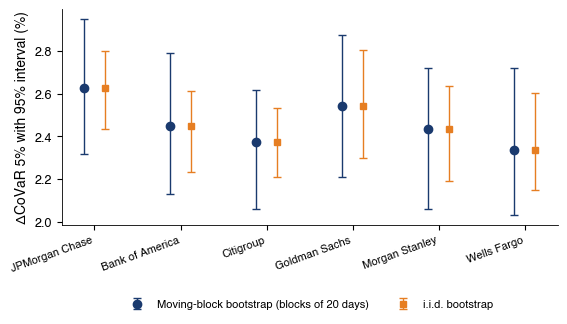

,b,var_i,covar,dcovar,lo,hi,iid_lo,iid_hi,var_sys
JPM,0.96,2.66,3.81,2.62,2.32,2.95,2.43,2.80,2.82
BAC,0.76,3.17,3.67,2.45,2.13,2.79,2.23,2.61,2.71
C,0.72,3.25,3.58,2.38,2.06,2.62,2.21,2.53,2.70
GS,0.89,2.79,3.93,2.54,2.21,2.87,2.30,2.81,2.81
MS,0.72,3.31,3.72,2.43,2.06,2.72,2.19,2.64,2.76
WFC,0.81,2.83,3.89,2.34,2.03,2.72,2.15,2.60,2.84


In [15]:
def b1_us_dcovar5():
    """Delta-CoVaR 5% pentru bancile americane: interval bootstrap pe blocuri vs i.i.d."""
    out = {}
    rng = np.random.default_rng(SEED)
    for i, k in enumerate(US):
        xs, xi = system_ex(k, US).values, R[k].values
        c = covar_static(xs, xi, 0.05)
        lo, hi = covar_boot(xs, xi, 0.05, B=200, block=20, seed=SEED + i)
        iid = []
        for _ in range(200):
            idx = rng.integers(0, len(xi), len(xi))
            iid.append(covar_static(xs[idx], xi[idx], 0.05)['dcovar'])
        out[k] = {'b': c['b'], 'var_i': c['var_i'], 'covar': c['covar'], 'dcovar': c['dcovar'], 'lo': lo, 'hi': hi,
                  'iid_lo': np.percentile(iid, 2.5), 'iid_hi': np.percentile(iid, 97.5), 'var_sys': c['var_sys']}
    return out


def fig_b1(res):
    ks = list(res)
    xs = np.arange(len(ks))
    fig, ax = plt.subplots(figsize=(6.4, 2.8))
    d = np.array([res[k]['dcovar'] for k in ks])
    ax.errorbar(xs - 0.12, d, yerr=[d - [res[k]['lo'] for k in ks], np.array([res[k]['hi'] for k in ks]) - d],
                fmt='o', color=MainBlue, capsize=3, lw=1, label='Moving-block bootstrap (blocks of 20 days)')
    ax.errorbar(xs + 0.12, d, yerr=[d - [res[k]['iid_lo'] for k in ks], np.array([res[k]['iid_hi'] for k in ks]) - d],
                fmt='s', color=Orange, capsize=3, lw=1, ms=4, label='i.i.d. bootstrap')
    ax.set_xticks(xs)
    ax.set_xticklabels([NAMES[k] for k in ks], fontsize=8, rotation=20, ha='right')
    ax.set_ylabel('ΔCoVaR 5% with 95% interval (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.3)
    save_fig('ch18_sem_b1')


b1 = b1_us_dcovar5()
fig_b1(b1)
pd.DataFrame(b1).T.round(2)

### B2. ΔCoVaR of European banks [Proposed]

- ΔCoVaR at 1% and 5%; rankings. Model: B1.
- Interpretation: does the ranking survive a change of α?

In [ ]:
# Your code here


### B3. MES and the break-even leverage [Solved]

- MES 5% with block-bootstrap intervals; L* with k = 8% and k = 5.5%.
- Interpretation: which region is most exposed to its market?

In [17]:
def mes_table():
    """MES 5% (fata de indicele regional), MES la pragul de -2% si LRMES, cu interval bootstrap pe blocuri."""
    rows = {}
    rng = np.random.default_rng(SEED)
    for k in ALL:
        m = R[REGION_INDEX[region_of(k)]].values
        x = R[k].values
        boot = []
        for _ in range(B_BOOT):
            idx = block_bootstrap_idx(len(x), 20, rng)
            boot.append(mes(x[idx], m[idx], 0.05))
        m2 = mes_threshold(x, m, -2.0)
        rows[k] = {'mes5': mes(x, m, 0.05), 'lo': np.percentile(boot, 2.5), 'hi': np.percentile(boot, 97.5),
                   'mes2': m2, 'n2': int((m < -2).sum()), 'lrmes': lrmes(m2), 'Lstar': breakeven_leverage(lrmes(m2)),
                   'Lstar55': breakeven_leverage(lrmes(m2), 0.055),
                   'beta': np.cov(x, m)[0, 1] / np.var(m, ddof=1), 'es5_m': -m[m <= np.quantile(m, 0.05)].mean(),
                   'var1': -np.quantile(x, 0.01)}
    return pd.DataFrame(rows).T


mes_table()[['mes5', 'lo', 'hi', 'mes2', 'lrmes', 'Lstar', 'Lstar55']].round(2)

,mes5,lo,hi,mes2,lrmes,Lstar,Lstar55
JPM,3.22,2.66,4.05,3.61,0.48,7.00,9.97
BAC,3.85,3.09,4.82,4.38,0.55,6.23,8.81
C,4.03,3.16,4.92,4.58,0.56,6.04,8.53
GS,3.34,2.84,4.09,3.78,0.49,6.82,9.70
MS,4.04,3.32,4.81,4.62,0.56,6.01,8.49
WFC,3.32,2.72,4.07,3.79,0.49,6.82,9.69
DBK,4.54,3.93,5.12,4.55,0.56,6.07,8.58
BNP,4.53,3.83,5.18,4.54,0.56,6.08,8.59
SAN,4.23,3.70,4.77,4.24,0.53,6.37,9.02
INGA,4.81,3.94,5.67,4.82,0.58,5.83,8.22


### B4. Does VaR rank banks like ΔCoVaR? [Proposed]

- Spearman correlation with a block-bootstrap interval. Model: B1, B3.
- Interpretation: what does this imply for bank-by-bank regulation?

In [ ]:
# Your code here


### B5. How robust is the connectedness index? [Solved]

- VAR orders 1–4, horizons 5, 10, 20; generalized vs Cholesky.
- Interpretation: which choice moves the index most?

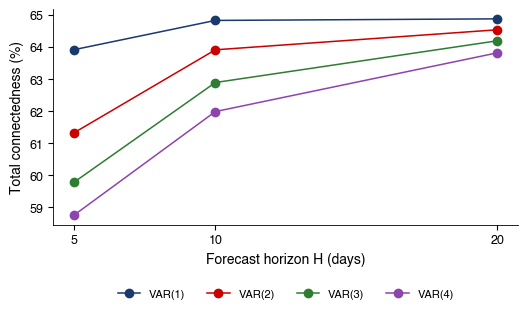

{'grid': {'p1_H5': np.float64(63.918739915151946),
  'p1_H10': np.float64(64.82856135138591),
  'p1_H20': np.float64(64.87746431358558),
  'p2_H5': np.float64(61.332315969413564),
  'p2_H10': np.float64(63.912446031455424),
  'p2_H20': np.float64(64.53665894080801),
  'p3_H5': np.float64(59.792634463637555),
  'p3_H10': np.float64(62.89236674722018),
  'p3_H20': np.float64(64.19282081807036),
  'p4_H5': np.float64(58.76700904619478),
  'p4_H10': np.float64(61.98674430224988),
  'p4_H20': np.float64(63.8169101735043)},
 'chol_us_first': np.float64(44.05699781048929),
 'chol_ro_first': np.float64(43.51917825118153),
 'gen': np.float64(64.82856135138591),
 'net_us_first': np.float64(65.92793495120091),
 'net_ro_first': np.float64(-95.93772147472195),
 'gen_net_us': np.float64(53.25030605377643)}

In [19]:
def b5_dy_sensitivity():
    """Indicele total pentru orizonturi H si ordine VAR p; generalizat vs Cholesky in doua ordini."""
    Y = V.values
    grid = {}
    for p in [1, 2, 3, 4]:
        A, S = var_fit(Y, p)
        for H in [5, 10, 20]:
            grid[f'p{p}_H{H}'] = spillover_table(gfevd(A, S, H), ALL)['total']
    A, S = var_fit(Y, 1)
    ch_us = spillover_table(cholesky_fevd(A, S, 10), ALL)
    ch_ro = spillover_table(cholesky_fevd(A, S, 10, order=list(range(len(ALL)))[::-1]), ALL)
    g = spillover_table(gfevd(A, S, 10), ALL)
    return {'grid': grid, 'chol_us_first': ch_us['total'], 'chol_ro_first': ch_ro['total'], 'gen': g['total'],
            'net_us_first': ch_us['net'][US].sum(), 'net_ro_first': ch_ro['net'][US].sum(),
            'gen_net_us': g['net'][US].sum()}


def fig_b5(res):
    fig, ax = plt.subplots(figsize=(6.0, 2.8))
    for p, c in zip([1, 2, 3, 4], [MainBlue, IDAred, Forest, Purple]):
        ax.plot([5, 10, 20], [res['grid'][f'p{p}_H{H}'] for H in [5, 10, 20]], 'o-', color=c, label=f'VAR({p})')
    ax.set_xticks([5, 10, 20])
    ax.set_xlabel('Forecast horizon H (days)')
    ax.set_ylabel('Total connectedness (%)')
    legend_outside_bottom(ax, ncol=4, y=-0.25)
    save_fig('ch18_sem_b5')


b5 = b5_dy_sensitivity()
fig_b5(b5)
b5

### B6. Did connectedness rise after 2020? [Proposed]

- Rolling index; post-2020 dummy with ordinary and Newey–West standard errors. Model: B5.
- Interpretation: which t-statistic do you trust?

In [ ]:
# Rolling connectedness index (input of B6)
tot, net = spill_rolling()
tot.to_csv(os.path.join(HERE, 'ch18_spill_rolling.csv'))

In [ ]:
# Your code here


### B7. The FRM penalty in one window [Solved]

- JPMorgan, 63 days, calm vs crisis window.
- Interpretation: why is the selected λ so small?

In [22]:
def b7_frm_window():
    """FRM intr-o fereastra: lambda GACV si legaturile active pentru JPMorgan (calm vs COVID-19)."""
    D = frm_design()
    out = {}
    for end in ['2019-06-28', '2020-03-31']:
        w = D.loc[:end].iloc[-63:]
        r = frm_window(w, 'JPM')
        names = [j for j in ALL if j != 'JPM'] + ['S&P 500 (t-1)', 'Euro Stoxx 50 (t-1)', 'VIX (t-1)']
        coef = pd.Series(r['coef'], index=names)
        act = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)
        out[end] = {'lambda': r['lambda'], 'df': r['df_sel'], 'active': {NAMES.get(k, k): v for k, v in act.head(4).items()},
                    'n_active': len(act), 'first': w.index[0]}
    return out


b7_frm_window()

{'2019-06-28': {'lambda': np.float64(4.548777947003778e-05),
  'df': 11,
  'active': {'Bank of America': 0.5171342439417581,
   'Santander': 0.25210736369375697,
   'Morgan Stanley': 0.18741215082539728,
   'ING': -0.11704134760804076},
  'n_active': 11,
  'first': Timestamp('2019-03-21 00:00:00')},
 '2020-03-31': {'lambda': np.float64(7.847599703514606e-05),
  'df': 12,
  'active': {'Bank of America': 0.39275080916987914,
   'Euro Stoxx 50 (t-1)': 0.37971898189105674,
   'BNP Paribas': 0.3420860962899162,
   'HSBC': 0.322214449023489},
  'n_active': 12,
  'first': Timestamp('2019-12-23 00:00:00')}}

### B8. Stress test of a Romanian bank portfolio [Proposed]

- 50% Banca Transilvania, 50% BRD; historical and hypothetical scenarios. Model: A7, B3.
- Interpretation: domestic political shock or global pandemic?

In [ ]:
# Your code here


## Part C — exposure of Romanian banks to euro-area banking stress [Proposed]

- Exposure CoVaR of Banca Transilvania and BRD given European bank distress; subperiods; rolling connectedness from European and US banks.

In [ ]:
# Your code here
